# Heart Disease Prediction — Notebook 1: Preprocessing & EDA

This notebook covers Loading the dataset, Handling missing values, Encoding categorical variables, Feature scaling, Exploratory data analysis (summary stats, distributions, correlation)

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Cleveland Heart Disease dataset
df = pd.read_csv('../data/heart_cleveland.csv')

# Quick look at shape and first few rows
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset shape: (297, 14)
Rows: 297, Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
# Data types and non-null counts
print("=" * 50)
print("Dataset Info:")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("Missing values per column:")
print("=" * 50)
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB

Missing values per column:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca     

In [4]:
# Summary statistics of all features
print("=" * 50)
print("Summary Statistics:")
print("=" * 50)
df.describe().T

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


Target class distribution:
condition
0    160
1    137
Name: count, dtype: int64

Class 0 (No disease): 160 (53.9%)
Class 1 (Disease):    137 (46.1%)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24924\2460139477.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='condition', data=df, palette=['#2ecc71', '#e74c3c'])


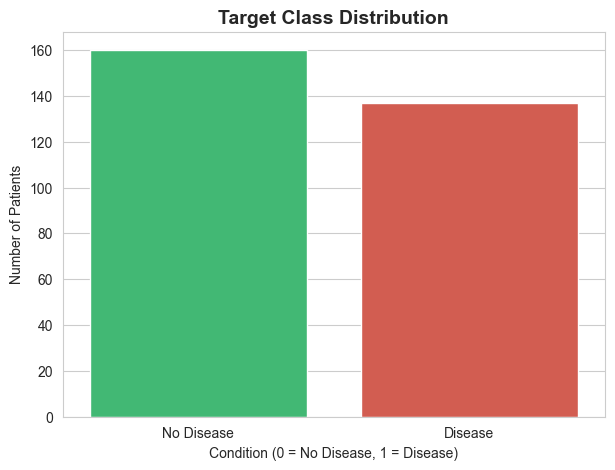

In [5]:
# Class distribution (is the dataset balanced?)
print("Target class distribution:")
print(df['condition'].value_counts())
print(f"\nClass 0 (No disease): {(df['condition'] == 0).sum()} ({(df['condition'] == 0).mean()*100:.1f}%)")
print(f"Class 1 (Disease):    {(df['condition'] == 1).sum()} ({(df['condition'] == 1).mean()*100:.1f}%)")

# Visualize
plt.figure(figsize=(7, 5))
sns.countplot(x='condition', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Target Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Condition (0 = No Disease, 1 = Disease)')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.savefig('../outputs/plots/04_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

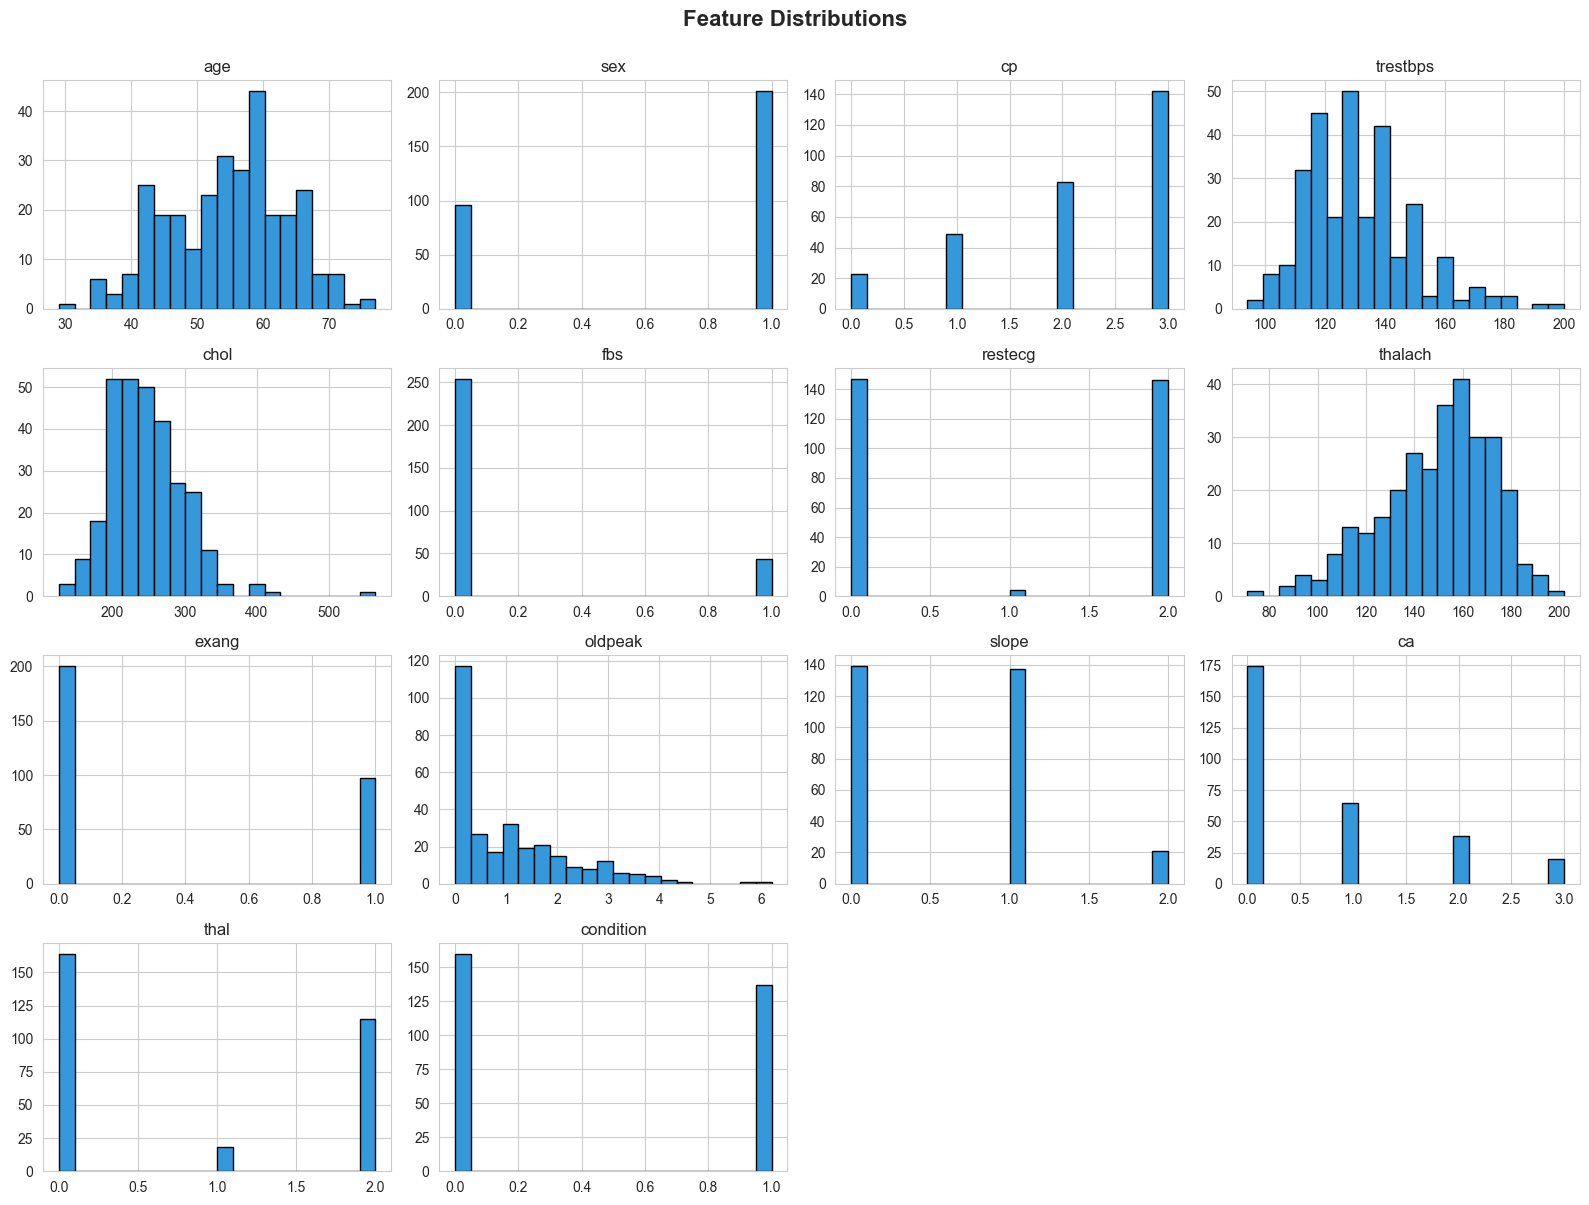

In [6]:
# Plot histograms of all numerical features
df.hist(bins=20, figsize=(16, 12), color='#3498db', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('../outputs/plots/05_feature_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24924\2919761668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=feature, data=df, ax=axes[i],
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24924\2919761668.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Disease', 'Disease'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24924\2919761668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=feature, data=df, ax=axes[i],
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24924\2919761668.py:11: UserWarning: set_ticklabels() should only be used with a fixed nu

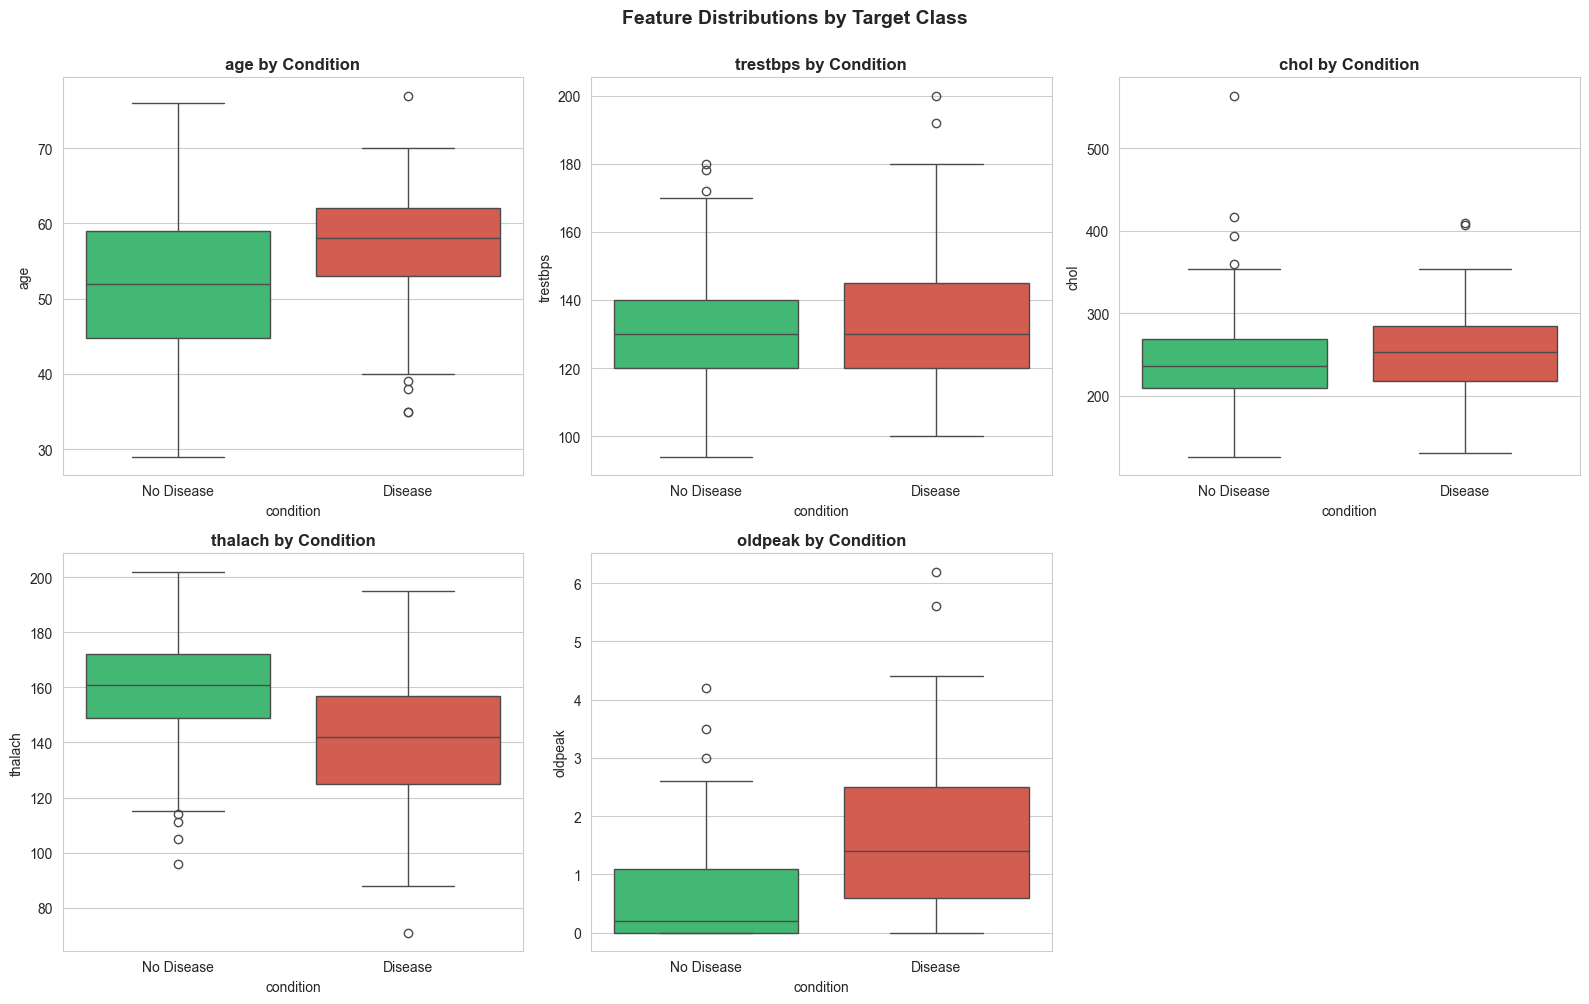

In [7]:
# Boxplots: how do features differ between disease/no-disease patients?
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x='condition', y=feature, data=df, ax=axes[i], 
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{feature} by Condition', fontweight='bold')
    axes[i].set_xticklabels(['No Disease', 'Disease'])

# Hide the empty 6th subplot
axes[5].axis('off')

plt.suptitle('Feature Distributions by Target Class', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('../outputs/plots/06_boxplots_by_class.png', dpi=100, bbox_inches='tight')
plt.show()

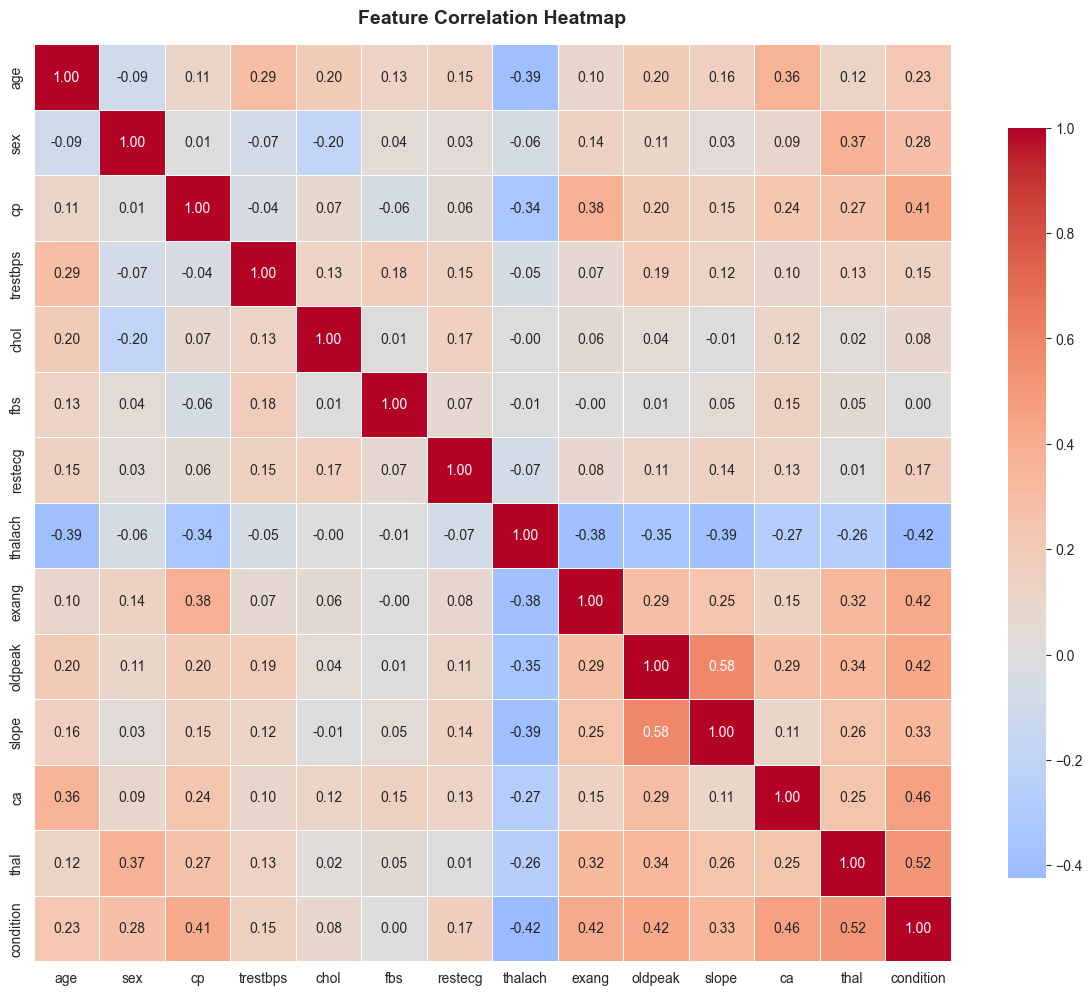


Correlation with target (condition):
thal        0.520516
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: condition, dtype: float64


In [8]:
# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/07_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Print correlations with the target, sorted
print("\nCorrelation with target (condition):")
print(correlation_matrix['condition'].drop('condition').sort_values(ascending=False))

In [9]:
# Identify categorical and numerical features
# These columns are already numeric in this dataset, but conceptually categorical
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

# Separate features (X) and target (y)
X = df.drop('condition', axis=1)
y = df['condition']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Features shape: (297, 13)
Target shape: (297,)


In [10]:
# Split data: 80% train, 20% test, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True)}")

Training set: (237, 13)
Test set:     (60, 13)

Train class balance:
condition
0    0.540084
1    0.459916
Name: proportion, dtype: float64

Test class balance:
condition
0    0.533333
1    0.466667
Name: proportion, dtype: float64


In [11]:
# Standardize numerical features (mean=0, std=1)
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("Numerical features after scaling (train):")
print(X_train_scaled[numerical_features].describe().T[['mean', 'std']].round(3))

Numerical features after scaling (train):
          mean    std
age       -0.0  1.002
trestbps  -0.0  1.002
chol       0.0  1.002
thalach    0.0  1.002
oldpeak    0.0  1.002


In [12]:
# Save preprocessed data so the next notebooks can load it directly
import os

os.makedirs('../outputs/processed_data', exist_ok=True)

X_train_scaled.to_csv('../outputs/processed_data/X_train.csv', index=False)
X_test_scaled.to_csv('../outputs/processed_data/X_test.csv', index=False)
y_train.to_csv('../outputs/processed_data/y_train.csv', index=False)
y_test.to_csv('../outputs/processed_data/y_test.csv', index=False)

print("Preprocessed data saved to outputs/processed_data/")
print(f"  - X_train.csv: {X_train_scaled.shape}")
print(f"  - X_test.csv:  {X_test_scaled.shape}")
print(f"  - y_train.csv: {y_train.shape}")
print(f"  - y_test.csv:  {y_test.shape}")

Preprocessed data saved to outputs/processed_data/
  - X_train.csv: (237, 13)
  - X_test.csv:  (60, 13)
  - y_train.csv: (237,)
  - y_test.csv:  (60,)


Preprocessing complete

- Dataset: 297 patients, 13 features + 1 target (condition)
- No missing values found
- Categorical features (sex, cp, fbs, restecg, exang, slope, ca, thal) were already encoded as integers
- Numerical features (age, trestbps, chol, thalach, oldpeak) standardised using `StandardScaler`
- 80/20 train-test split with stratification to preserve class balance
- Scaler fitted on training data only (no data leakage)

Key insights from EDA
- Roughly balanced classes (~54% no disease, ~46% disease)
- `cp`, `thalach`, `exang`, `oldpeak`, `ca`, `thal` show the strongest correlations with the target
- `thalach` and `oldpeak` show clear separation between classes — likely strong predictors